# 11 — Final Forward Decision, Submission Validation, and Scoring v2

This notebook extends the final forward-decision notebook with a **competition-aligned scoring section**.

It includes two complementary views:

1. **Raw official proxy score**  
   Uses the official formula structure directly:
   - MAE for `P80`, `R95`, `R50_fines`, `R50_oversize`
   - sMAPE for `fines_frac`, `oversize_frac` when full predictions are available  
   - score = `100 / (1 + weighted_error)`

2. **Official-weighted relative LOGO proxy**  
   Uses relative errors for interpretability and strategy comparison:
   - relative MAE = MAE / mean(|y_true|)
   - sMAPE for fraction targets when possible
   - same official target weights

> **Important**  
> True test labels are not public, so all scores here are **validation proxies**, not official leaderboard scores.  
> The relative proxy is recommended for presentation because raw absolute MAE is scale-sensitive and distance targets numerically dominate the score.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
SUBMISSIONS_DIR = OUTPUTS_DIR / "submissions"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = OUTPUTS_DIR / "figures"

for p in [OUTPUTS_DIR, SUBMISSIONS_DIR, REPORTS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Submissions:", SUBMISSIONS_DIR)
print("Reports:", REPORTS_DIR)
print("Figures:", FIGURES_DIR)


Project root: /home/alouiyaz/projects/boom-challenge-ejecta-prediction
Submissions: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/submissions
Reports: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/reports
Figures: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/figures


## 1. Official scoring definition

Official forward scoring weights:

| Target | Metric | Weight |
|---|---:|---:|
| P80 | MAE | 0.30 |
| R95 | MAE | 0.20 |
| fines_frac | sMAPE | 0.15 |
| oversize_frac | sMAPE | 0.15 |
| R50_fines | MAE | 0.10 |
| R50_oversize | MAE | 0.10 |

\[
\text{forward\_prediction\_score} = \frac{100}{1+\text{weighted\_error}}
\]

\[
\text{weighted\_error} = \sum_i w_i \times error_i
\]

The raw official score is scale-sensitive because distance targets are measured on much larger numerical ranges than fraction targets.  
Therefore, for model comparison and presentation, we also report an **official-weighted relative proxy**.


In [2]:
target_cols = ["P80", "fines_frac", "oversize_frac", "R95", "R50_fines", "R50_oversize"]
distance_cols = ["R95", "R50_fines", "R50_oversize"]
fraction_cols = ["fines_frac", "oversize_frac"]
mae_cols = ["P80", "R95", "R50_fines", "R50_oversize"]

OFFICIAL_TARGET_WEIGHTS = {
    "P80": 0.30,
    "R95": 0.20,
    "fines_frac": 0.15,
    "oversize_frac": 0.15,
    "R50_fines": 0.10,
    "R50_oversize": 0.10,
}

weights_df = pd.DataFrame(
    [{"target": t, "metric": "sMAPE" if t in fraction_cols else "MAE", "weight": w}
     for t, w in OFFICIAL_TARGET_WEIGHTS.items()]
).sort_values("weight", ascending=False)

display(weights_df)

print("P80 + R95 combined weight:", OFFICIAL_TARGET_WEIGHTS["P80"] + OFFICIAL_TARGET_WEIGHTS["R95"])
print("Distance targets combined weight:", sum(OFFICIAL_TARGET_WEIGHTS[t] for t in distance_cols))


,target,metric,weight
0,P80,MAE,0.30
1,R95,MAE,0.20
2,fines_frac,sMAPE,0.15
3,oversize_frac,sMAPE,0.15
4,R50_fines,MAE,0.10
5,R50_oversize,MAE,0.10


P80 + R95 combined weight: 0.5
Distance targets combined weight: 0.4


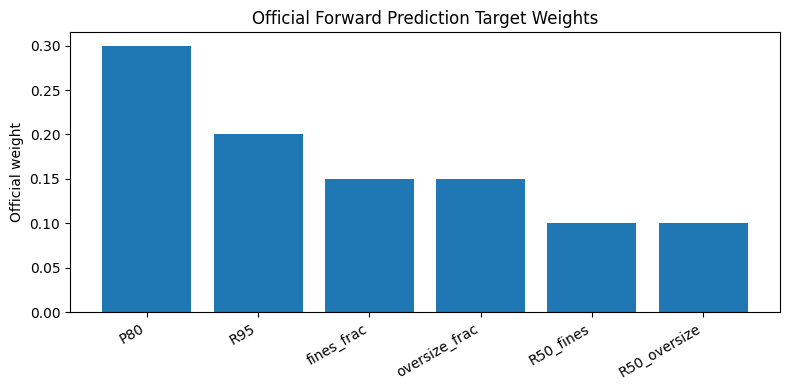

Saved: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/figures/official_forward_target_weights.png


In [3]:
plt.figure(figsize=(8, 4))
plt.bar(weights_df["target"], weights_df["weight"])
plt.title("Official Forward Prediction Target Weights")
plt.ylabel("Official weight")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

weights_plot_path = FIGURES_DIR / "official_forward_target_weights.png"
plt.savefig(weights_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", weights_plot_path)


## 2. Reusable official scoring functions

These functions should also be copied into the repository source code, for example:

```text
src/boom_challenge/evaluation.py
```

They can compute the true official score if the ground-truth test labels are available.


In [4]:
def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_pred - y_true)))


def relative_mae(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_pred - y_true)) / (np.mean(np.abs(y_true)) + eps))


def smape(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(
        2.0 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + eps)
    ))


def official_target_error(y_true, y_pred, target):
    if target in fraction_cols:
        return smape(y_true, y_pred)
    return mae(y_true, y_pred)


def official_relative_target_error(y_true, y_pred, target):
    if target in fraction_cols:
        return smape(y_true, y_pred)
    return relative_mae(y_true, y_pred)


def forward_prediction_score(y_true: pd.DataFrame, y_pred: pd.DataFrame, weights=None):
    """Raw official-style score. Use only when true labels and full predictions are available."""
    if weights is None:
        weights = OFFICIAL_TARGET_WEIGHTS

    rows = []
    weighted_error = 0.0

    for target, weight in weights.items():
        err = official_target_error(y_true[target], y_pred[target], target)
        contribution = weight * err
        weighted_error += contribution
        rows.append({
            "target": target,
            "metric": "sMAPE" if target in fraction_cols else "MAE",
            "weight": weight,
            "error": err,
            "weighted_contribution": contribution,
        })

    score = 100.0 / (1.0 + weighted_error)
    return float(score), float(weighted_error), pd.DataFrame(rows)


def forward_prediction_relative_score(y_true: pd.DataFrame, y_pred: pd.DataFrame, weights=None):
    """Official-weighted relative validation proxy. Useful for model comparison and presentation."""
    if weights is None:
        weights = OFFICIAL_TARGET_WEIGHTS

    rows = []
    weighted_error = 0.0

    for target, weight in weights.items():
        err = official_relative_target_error(y_true[target], y_pred[target], target)
        contribution = weight * err
        weighted_error += contribution
        rows.append({
            "target": target,
            "metric": "sMAPE" if target in fraction_cols else "relative_MAE",
            "weight": weight,
            "relative_error": err,
            "weighted_relative_contribution": contribution,
        })

    score = 100.0 / (1.0 + weighted_error)
    return float(score), float(weighted_error), pd.DataFrame(rows)


## 3. Final file validation

This section validates the final CSV files.


In [5]:
expected_prediction_cols = ["scenario_id"] + target_cols
expected_design_cols = [
    "submission_id", "energy", "angle_rad", "coupling", "strength",
    "porosity", "gravity", "atmosphere", "shape_factor",
]


def validate_prediction_submission(df, name):
    assert df.shape == (492, 7), f"{name}: expected shape (492, 7), got {df.shape}"
    assert df.columns.tolist() == expected_prediction_cols, f"{name}: wrong columns"
    assert df["scenario_id"].tolist() == list(range(492)), f"{name}: scenario_id must be 0..491"
    assert np.isfinite(df.drop(columns=["scenario_id"]).values).all(), f"{name}: contains non-finite values"
    assert (df[["P80", "R95", "R50_fines", "R50_oversize"]] >= 0).all().all(), f"{name}: negative size or distance value"
    assert ((df[["fines_frac", "oversize_frac"]] >= 0) &
            (df[["fines_frac", "oversize_frac"]] <= 1)).all().all(), f"{name}: fraction outside [0, 1]"
    print(f"{name}: prediction format OK")


def validate_design_submission(df):
    assert df.shape == (20, 9), f"design_submission: expected shape (20, 9), got {df.shape}"
    assert df.columns.tolist() == expected_design_cols, "design_submission: wrong columns"
    assert df["submission_id"].tolist() == list(range(20)), "design_submission: submission_id must be 0..19"
    assert np.isfinite(df.drop(columns=["submission_id"]).values).all(), "design_submission: contains non-finite values"
    print("design_submission: format OK")


prediction_path = SUBMISSIONS_DIR / "prediction_submission.csv"
design_path = SUBMISSIONS_DIR / "design_submission.csv"

if prediction_path.exists():
    prediction_submission = pd.read_csv(prediction_path)
    validate_prediction_submission(prediction_submission, "prediction_submission.csv")
    display(prediction_submission.head())
else:
    print("Missing:", prediction_path)

if design_path.exists():
    design_submission = pd.read_csv(design_path)
    validate_design_submission(design_submission)
    display(design_submission.head())
else:
    print("Missing:", design_path)


prediction_submission.csv: prediction format OK


,scenario_id,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
0,0,120.852192,0.120046,0.208373,1064.238127,1012.805657,448.529033
1,1,113.668032,0.048219,0.158274,180.340190,191.185816,88.486206
2,2,149.740914,0.121343,0.384067,1306.856464,1316.118523,541.277606
3,3,162.227452,0.008732,0.543184,731.377793,891.581710,418.480874
4,4,137.978607,0.047156,0.357337,152.512030,142.451662,60.233150


design_submission: format OK


,submission_id,energy,angle_rad,coupling,strength,porosity,gravity,atmosphere,shape_factor
0,0,3.598016,0.797647,1.291533,2.024534,0.304489,9.851536,0.422767,1.303159
1,1,3.219857,0.653336,0.937745,1.371766,0.268351,10.031512,0.819009,0.775107
2,2,3.883410,0.550208,0.754591,1.428060,0.294039,9.893283,0.800587,0.798041
3,3,2.769840,0.856038,0.933836,1.186456,0.266355,9.856101,0.429999,1.214199
4,4,3.491508,0.545414,1.620353,2.249113,0.264882,9.960773,0.715197,0.816463


## 4. LOGO-based scoring proxies from aggregate reports

This section uses existing LOGO report files.

### Raw official proxy

Uses aggregate LOGO MAE values.  
For distance targets, this follows the official MAE structure.  
For fraction targets, this is only a proxy because true sMAPE needs full predictions.

### Relative LOGO proxy

Uses relative MAE for size/distance targets and approximate fraction errors.  
This is more interpretable for model comparison and presentation.


In [6]:
logo_summary_path = REPORTS_DIR / "16_logo_summary_by_strategy.csv"
logo_metrics_path = REPORTS_DIR / "16_logo_metrics_by_strategy_target.csv"

if not logo_metrics_path.exists():
    raise FileNotFoundError(f"Missing {logo_metrics_path}. Run the LOGO validation notebook first.")

logo_metrics = pd.read_csv(logo_metrics_path)

display(
    logo_metrics
    .sort_values(["target", "normalized_MAE"])
    [["target", "strategy", "MAE", "RMSE", "R2", "P95_AE", "Bias", "normalized_MAE"]]
)

if logo_summary_path.exists():
    logo_summary = pd.read_csv(logo_summary_path)
    display(logo_summary.sort_values("mean_norm_MAE"))
else:
    logo_summary = None
    print("Missing:", logo_summary_path)


,target,strategy,MAE,RMSE,R2,P95_AE,Bias,normalized_MAE
0,P80,base,7.841240,10.349198,0.975220,21.382564,0.437683,0.119249
6,P80,hybrid_w_0.65,7.841240,10.349198,0.975220,21.382564,0.437683,0.119249
12,P80,alpha25,7.841240,10.349198,0.975220,21.382564,0.437683,0.119249
18,P80,physics_residual,7.841240,10.349198,0.975220,21.382564,0.437683,0.119249
10,R50_fines,hybrid_w_0.65,85.758140,122.130095,0.755231,277.177188,-18.566182,0.347341
22,R50_fines,physics_residual,121.285667,173.513075,0.505945,393.643866,-51.888721,0.491237
16,R50_fines,alpha25,188.334070,223.560726,0.179834,444.724439,-22.595067,0.762799
4,R50_fines,base,224.926193,261.725704,-0.124096,508.029820,-23.938028,0.911006
11,R50_oversize,hybrid_w_0.65,41.672160,58.567386,0.708187,123.138779,-3.474324,0.384298
23,R50_oversize,physics_residual,47.787989,73.614215,0.538983,167.797385,-22.860046,0.440698


,strategy,mean_norm_MAE,mean_R2,mean_P95_AE,mean_abs_bias
0,hybrid_w_0.65,0.221285,0.859072,111.932172,6.712336
1,physics_residual,0.261173,0.775831,148.296118,19.438114
2,alpha25,0.392738,0.615040,176.524145,8.890867
3,base,0.453561,0.492291,201.447550,9.617044


In [7]:
# Load train labels to compute target means for relative errors.
FORWARD_DIR = PROJECT_ROOT / "data" / "raw" / "forward_prediction"
labels_path = FORWARD_DIR / "train_labels.csv"

if labels_path.exists():
    y_train = pd.read_csv(labels_path)[target_cols]
    target_means = y_train.abs().mean().to_dict()
    display(pd.DataFrame([{"target": k, "mean_abs_train": v} for k, v in target_means.items()]))
else:
    y_train = None
    target_means = {}
    print("Missing labels file. Relative score will use LOGO normalized_MAE if available.")


,target,mean_abs_train
0,P80,171.891639
1,fines_frac,0.043865
2,oversize_frac,0.513737
3,R95,253.260470
4,R50_fines,310.884622
5,R50_oversize,126.181143


In [8]:
proxy_rows = []

for strategy, group in logo_metrics.groupby("strategy"):
    row = {"strategy": strategy}

    raw_weighted_error = 0.0
    relative_weighted_error = 0.0

    for target, weight in OFFICIAL_TARGET_WEIGHTS.items():
        target_row = group[group["target"] == target]
        if target_row.empty:
            row[f"{target}_raw_error_proxy"] = np.nan
            row[f"{target}_relative_error_proxy"] = np.nan
            continue

        mae_value = float(target_row["MAE"].iloc[0])

        # Raw official proxy:
        # For MAE targets, this is aligned with official MAE.
        # For fraction targets, this is MAE proxy because true sMAPE cannot be recovered from aggregate MAE.
        raw_error_proxy = mae_value

        # Relative diagnostic proxy:
        # For MAE targets, MAE / mean(|target|).
        # For fraction targets, this remains an approximate proxy unless full OOF predictions are available.
        if target in target_means and target not in fraction_cols:
            relative_error_proxy = mae_value / (target_means[target] + 1e-9)
        elif "normalized_MAE" in target_row.columns:
            relative_error_proxy = float(target_row["normalized_MAE"].iloc[0])
        else:
            relative_error_proxy = mae_value

        if target in fraction_cols:
            # We keep the MAE proxy for fractions, clearly documented.
            # If full OOF predictions are available later, replace this by true sMAPE.
            relative_error_proxy = mae_value

        row[f"{target}_raw_error_proxy"] = raw_error_proxy
        row[f"{target}_raw_weighted_proxy"] = weight * raw_error_proxy
        row[f"{target}_relative_error_proxy"] = relative_error_proxy
        row[f"{target}_relative_weighted_proxy"] = weight * relative_error_proxy

        raw_weighted_error += weight * raw_error_proxy
        relative_weighted_error += weight * relative_error_proxy

    row["raw_weighted_error_proxy"] = raw_weighted_error
    row["raw_score_proxy"] = 100.0 / (1.0 + raw_weighted_error)

    row["relative_weighted_error_proxy"] = relative_weighted_error
    row["relative_score_proxy"] = 100.0 / (1.0 + relative_weighted_error)

    proxy_rows.append(row)

score_proxy_df = (
    pd.DataFrame(proxy_rows)
    .sort_values("relative_score_proxy", ascending=False)
    .reset_index(drop=True)
)

display(score_proxy_df[[
    "strategy",
    "raw_weighted_error_proxy",
    "raw_score_proxy",
    "relative_weighted_error_proxy",
    "relative_score_proxy",
]])

score_proxy_path = REPORTS_DIR / "11_scoring_v2_raw_and_relative_logo_proxy.csv"
score_proxy_df.to_csv(score_proxy_path, index=False)
print("Saved:", score_proxy_path)


,strategy,raw_weighted_error_proxy,raw_score_proxy,relative_weighted_error_proxy,relative_score_proxy
0,hybrid_w_0.65,29.695693,3.257786,0.136988,87.951655
1,physics_residual,35.722271,2.723143,0.160616,86.161136
2,alpha25,57.438058,1.711214,0.252793,79.821648
3,base,67.239189,1.465434,0.293725,77.296173


Saved: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/reports/11_scoring_v2_raw_and_relative_logo_proxy.csv


## 5. Presentation-ready scoring plots

Use the **relative score proxy** in the presentation.  
Do not present it as an official leaderboard score.


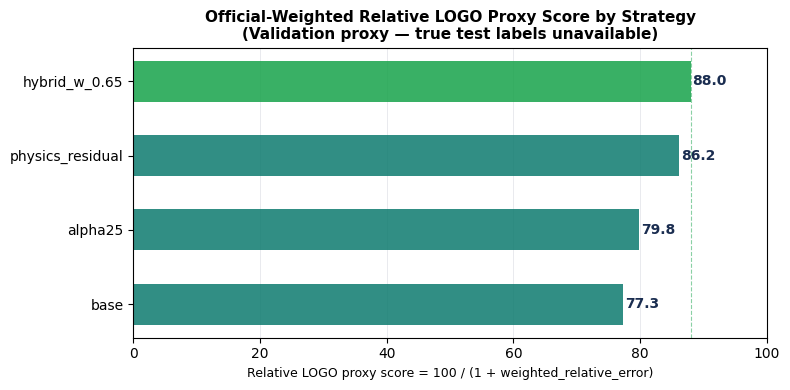

Saved: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/figures/scoring_v2_relative_logo_proxy_score_by_strategy.png


In [15]:
# In [9] — replace the relative score plot with this version

plot_df = score_proxy_df.sort_values("relative_score_proxy", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(plot_df["strategy"], plot_df["relative_score_proxy"],
               color=["#16A34A" if s == plot_df["relative_score_proxy"].max() 
                      else "#0D7A6E" for s in plot_df["relative_score_proxy"]],
               alpha=0.85, height=0.55)

# Annotate values on bars
for bar, val in zip(bars, plot_df["relative_score_proxy"]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va="center", fontsize=10, fontweight="bold", color="#1A2D50")

ax.set_xlim(0, 100)
ax.set_xlabel("Relative LOGO proxy score = 100 / (1 + weighted_relative_error)", fontsize=9)
ax.set_title("Official-Weighted Relative LOGO Proxy Score by Strategy\n"
             "(Validation proxy — true test labels unavailable)", fontsize=11, fontweight="bold")
ax.axvline(x=plot_df["relative_score_proxy"].max(), color="#16A34A",
           linestyle="--", linewidth=0.8, alpha=0.5)
ax.xaxis.grid(True, color="#E5E7EB", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()

relative_score_plot_path = FIGURES_DIR / "scoring_v2_relative_logo_proxy_score_by_strategy.png"
plt.savefig(relative_score_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", relative_score_plot_path)

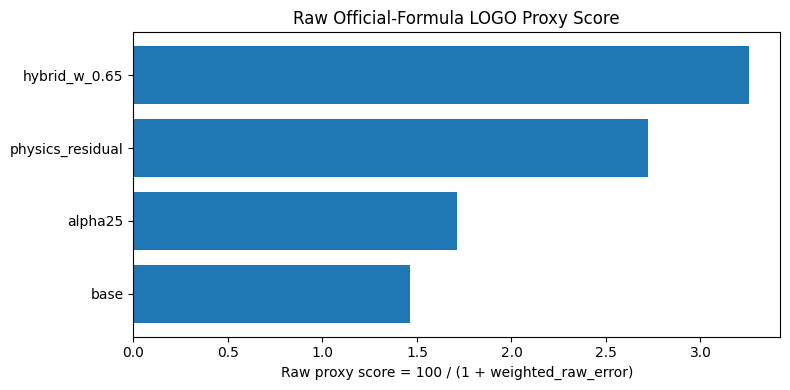

Saved: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/figures/scoring_v2_raw_logo_proxy_score_by_strategy.png


In [10]:
plot_df = score_proxy_df.sort_values("raw_score_proxy", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(plot_df["strategy"], plot_df["raw_score_proxy"])
plt.title("Raw Official-Formula LOGO Proxy Score")
plt.xlabel("Raw proxy score = 100 / (1 + weighted_raw_error)")
plt.tight_layout()

raw_score_plot_path = FIGURES_DIR / "scoring_v2_raw_logo_proxy_score_by_strategy.png"
plt.savefig(raw_score_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", raw_score_plot_path)


## 6. Weighted contribution by target

This plot explains *why* the raw official proxy is hard to interpret: distance targets dominate because of their numerical scale.

For the presentation, prefer the **relative contribution plot**.


In [11]:
SELECTED_STRATEGY = "hybrid_w_0.65"

if SELECTED_STRATEGY not in score_proxy_df["strategy"].values:
    SELECTED_STRATEGY = score_proxy_df.iloc[0]["strategy"]
    print("Selected strategy not found. Using:", SELECTED_STRATEGY)

selected = score_proxy_df[score_proxy_df["strategy"] == SELECTED_STRATEGY].iloc[0]

contrib_rows = []
for target, weight in OFFICIAL_TARGET_WEIGHTS.items():
    contrib_rows.append({
        "target": target,
        "official_weight": weight,
        "raw_error_proxy": selected[f"{target}_raw_error_proxy"],
        "raw_weighted_proxy": selected[f"{target}_raw_weighted_proxy"],
        "relative_error_proxy": selected[f"{target}_relative_error_proxy"],
        "relative_weighted_proxy": selected[f"{target}_relative_weighted_proxy"],
    })

contrib_df = pd.DataFrame(contrib_rows).sort_values("relative_weighted_proxy", ascending=False)

display(contrib_df)

contrib_path = REPORTS_DIR / f"11_scoring_v2_{SELECTED_STRATEGY}_target_contributions.csv"
contrib_df.to_csv(contrib_path, index=False)
print("Saved:", contrib_path)


,target,official_weight,raw_error_proxy,raw_weighted_proxy,relative_error_proxy,relative_weighted_proxy
1,R95,0.20,72.976140,14.595228,0.288147,0.057629
5,R50_oversize,0.10,41.672160,4.167216,0.330257,0.033026
4,R50_fines,0.10,85.758140,8.575814,0.275852,0.027585
0,P80,0.30,7.841240,2.352372,0.045617,0.013685
3,oversize_frac,0.15,0.027178,0.004077,0.027178,0.004077
2,fines_frac,0.15,0.006575,0.000986,0.006575,0.000986


Saved: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/reports/11_scoring_v2_hybrid_w_0.65_target_contributions.csv


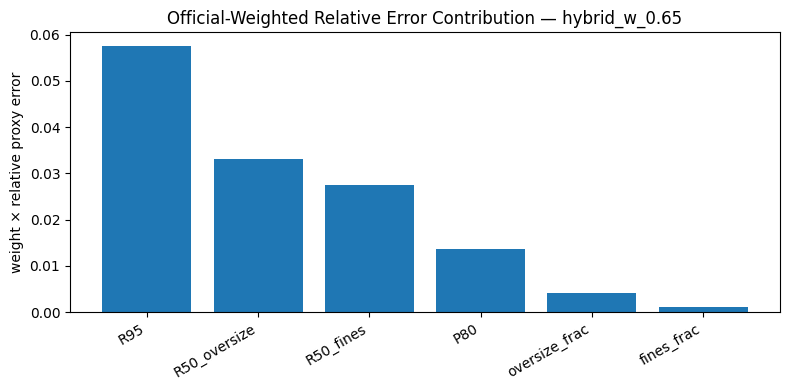

Saved: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/figures/scoring_v2_relative_weighted_contribution_hybrid_w_0.65.png


In [12]:
plt.figure(figsize=(8, 4))
plt.bar(contrib_df["target"], contrib_df["relative_weighted_proxy"])
plt.title(f"Official-Weighted Relative Error Contribution — {SELECTED_STRATEGY}")
plt.ylabel("weight × relative proxy error")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

safe_strategy = SELECTED_STRATEGY.replace("/", "_")
relative_contrib_plot_path = FIGURES_DIR / f"scoring_v2_relative_weighted_contribution_{safe_strategy}.png"
plt.savefig(relative_contrib_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", relative_contrib_plot_path)


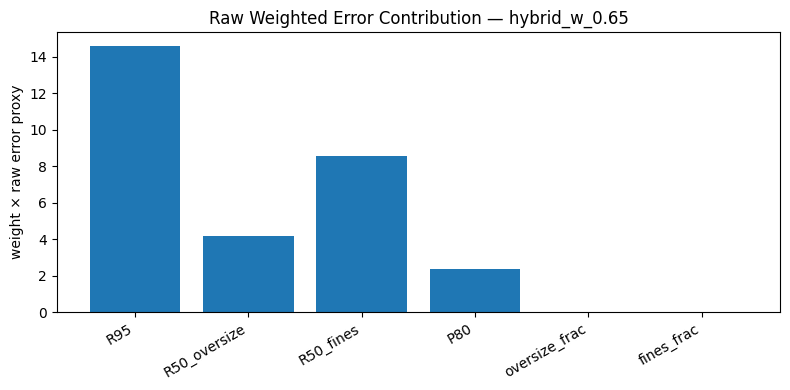

Saved: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/figures/scoring_v2_raw_weighted_contribution_hybrid_w_0.65.png


In [13]:
plt.figure(figsize=(8, 4))
plt.bar(contrib_df["target"], contrib_df["raw_weighted_proxy"])
plt.title(f"Raw Weighted Error Contribution — {SELECTED_STRATEGY}")
plt.ylabel("weight × raw error proxy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

raw_contrib_plot_path = FIGURES_DIR / f"scoring_v2_raw_weighted_contribution_{safe_strategy}.png"
plt.savefig(raw_contrib_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", raw_contrib_plot_path)


## 7. Final presentation wording

Recommended wording:

> I implemented the official scoring formula in the final notebook.  
> Because true test labels are unavailable, the computed values are validation proxies.  
> The raw official proxy is scale-sensitive because distance errors are measured on much larger numerical ranges.  
> Therefore, I also report an official-weighted relative LOGO proxy, which is more useful for comparing strategies and explaining the model choice.

Recommended slide:

- Show official weights.
- Mention that P80 + R95 = 50% of the forward score.
- Show the **relative LOGO proxy score** chart, not the raw score chart.
- Add the note: “Validation proxy, not leaderboard score.”


In [14]:
presentation_summary = pd.DataFrame([
    {
        "message": "P80 + R95 represent 50% of official forward scoring weight.",
        "value": OFFICIAL_TARGET_WEIGHTS["P80"] + OFFICIAL_TARGET_WEIGHTS["R95"],
    },
    {
        "message": "Distance targets represent 40% of official forward scoring weight.",
        "value": sum(OFFICIAL_TARGET_WEIGHTS[t] for t in distance_cols),
    },
    {
        "message": f"Selected strategy: {SELECTED_STRATEGY}",
        "value": selected["relative_score_proxy"],
    },
    {
        "message": "Use relative LOGO proxy for presentation, not as official leaderboard score.",
        "value": np.nan,
    },
])

display(presentation_summary)


,message,value
0,P80 + R95 represent 50% of official forward sc...,0.500000
1,Distance targets represent 40% of official for...,0.400000
2,Selected strategy: hybrid_w_0.65,87.951655
3,"Use relative LOGO proxy for presentation, not ...",NaN


## 8. Final note

The key result is not the absolute value of the proxy score.  
The key result is that the validation is aligned with:

1. official scoring weights;
2. OOD gravity risk;
3. target-specific model design;
4. final submission reproducibility.
